# Yield Curve Validation

This notebook validates a reusable yield-curve component for option valuation. It tests zero-rate interpolation, discount-factor calculations and the shape of an illustrative term structure.

The rates below are synthetic and are used only to demonstrate the behaviour of the implementation.

## 1. Setup

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np

from src.yieldcurve import YieldCurve

## 2. Construct an illustrative term structure

The curve is defined by continuously compounded zero rates at a set of observed maturities. Rates at intermediate maturities are obtained through linear interpolation.

In [2]:
maturities = [0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
zero_rates = [0.042, 0.043, 0.045, 0.048, 0.052, 0.055]

curve = YieldCurve(
    maturities=maturities,
    zero_rates=zero_rates,
    compounding="continuous"
)

## 3. Check interpolated rates and discount factors

In [3]:
test_maturities = [0.75, 3.0, 7.0]

for T in test_maturities:
    zero_rate = curve.get_zero_rate(T)
    discount_factor = curve.get_discount_factor(T)
    print(
        f"T={T:.2f} years | "
        f"zero rate={zero_rate:.2%} | "
        f"discount factor={discount_factor:.4f}"
    )

T=0.75 years | zero rate=4.40% | discount factor=0.9675
T=3.00 years | zero rate=4.93% | discount factor=0.8624
T=7.00 years | zero rate=5.32% | discount factor=0.6891


The interpolated zero rates increase from **4.40% at 0.75 years** to **5.32% at 7 years**. Over the same maturities, discount factors fall from **0.9675** to **0.6891**, as expected for positive interest rates.

## 4. Visualise the interpolated curve

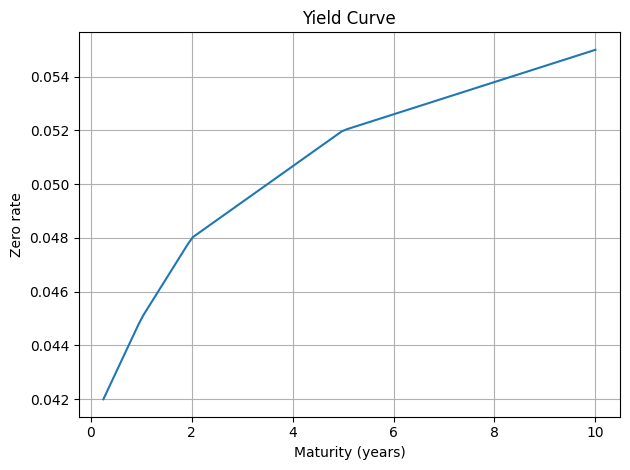

In [4]:
curve.plot(max_maturity=10.0)

## 5. Findings

- Linear interpolation produces a smooth term structure between the supplied maturities.
- Discount factors remain positive and decline with maturity under the illustrative upward-sloping curve.
- Centralising rate interpolation and discounting in one object allows the same curve to be reused consistently across derivative contracts.